# Pre-processing the field data to traning data

In [13]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import re
import unicodedata
from difflib import SequenceMatcher

# -------------------------------------------------------------------
# INPUT PATHS
# -------------------------------------------------------------------

# 1. Load both shapefiles
old_input = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco"
    r"\Vegetation Cover and Food Availability Studies"
    r"\Vegetation Phytosociological Survey1015.shp"
)

new_input = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco"
    r"\Vegetation Cover and Food Availability Studies"
    r"\Phytosociological_habitat_Tamlelt_06102026.shp"
)


def resolve_shapefile(path):
    """Resolve a path that may be a .shp, shapefile basename, or folder."""
    
    if path.is_file():
        return path

    # Try adding .shp
    shp_version = path.with_suffix(".shp")
    if shp_version.is_file():
        return shp_version

    # If it is a folder, find shapefiles inside
    if path.is_dir():
        candidates = list(path.glob("*.shp"))

        if len(candidates) == 1:
            return candidates[0]

        elif len(candidates) > 1:
            print("Multiple shapefiles found:")
            for f in candidates:
                print("  ", f)
            raise ValueError("More than one shapefile found. Please choose one.")

    raise FileNotFoundError(f"Could not find shapefile: {path}")


old_path = resolve_shapefile(old_input)
new_path = resolve_shapefile(new_input)

print("OLD:", old_path)
print("NEW:", new_path)

old_gdf = gpd.read_file(old_path)
new_gdf = gpd.read_file(new_path)

print("\nLoaded successfully.")
print("Old records:", len(old_gdf))
print("New records:", len(new_gdf))

OLD: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Vegetation Phytosociological Survey1015.shp
NEW: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Phytosociological_habitat_Tamlelt_06102026.shp

Loaded successfully.
Old records: 1943
New records: 198


In [14]:
# 2. Inspect the two datasets

def inspect_gdf(gdf, name):
    print("=" * 80)
    print(name)
    print("=" * 80)

    print("Number of records:", len(gdf))
    print("CRS:", gdf.crs)
    print("Geometry types:")
    print(gdf.geometry.geom_type.value_counts(dropna=False))

    rows = []

    for col in gdf.columns:
        if col == gdf.geometry.name:
            continue

        s = gdf[col]

        samples = (
            s.dropna()
             .astype(str)
             .drop_duplicates()
             .head(5)
             .tolist()
        )

        rows.append({
            "field": col,
            "dtype": str(s.dtype),
            "missing": s.isna().sum(),
            "missing_%": round(s.isna().mean() * 100, 1),
            "unique": s.nunique(dropna=True),
            "sample_values": " | ".join(samples)
        })

    return pd.DataFrame(rows)


old_summary = inspect_gdf(old_gdf, "PREVIOUS-YEAR DATA")
display(old_summary)

new_summary = inspect_gdf(new_gdf, "2026 DATA")
display(new_summary)

PREVIOUS-YEAR DATA
Number of records: 1943
CRS: EPSG:4326
Geometry types:
Point    1943
Name: count, dtype: int64


,field,dtype,missing,missing_%,unique,sample_values
0,Station_ID,int64,0,0.0,1941,34883 | 100281 | 176637 | 74289 | 81553
1,Station_Na,object,0,0.0,1670,Maille 78SE | XA28NW4 | Maille 09NW | Maille 7...
2,Station_Da,object,0,0.0,310,12-Mar-08 | 21-Apr-15 | 17-Mar-09 | 3-Mar-08 |...
3,Latitude,float64,0,0.0,1923,32.3816 | 32.41656 | 32.50987 | 32.27989 | 33....
4,Longitude,float64,0,0.0,1931,-2.18346 | -1.7133 | -1.91196 | -2.2131 | -2.2...
5,Elevation,int64,0,0.0,921,1051 | 1212 | 1134 | 1039 | 1064
6,Precision,int64,0,0.0,10,5 | 10 | 1 | 0 | 14
7,Area_M2,int64,0,0.0,54,120 | 150 | 160 | 200 | 250
8,Exposure,object,518,26.7,11,No | None | NW | W | N
9,Slope_Clas,object,998,51.4,5,"[0;0,5°] | [0,5°;6°] | [6°;27°] | [27°;45°] | ..."


2026 DATA
Number of records: 198
CRS: EPSG:4326
Geometry types:
Point    198
Name: count, dtype: int64


,field,dtype,missing,missing_%,unique,sample_values
0,Station_ID,object,0,0.0,3,"No phytosociology relevé, only field observati..."
1,Station_Na,object,137,69.2,61,WA69NW6 | WA69NW1 | WC07NW2 | WC17NW1 | XA08NW2
2,Latitude,float64,0,0.0,197,32.44596 | 32.53156 | 32.52737 | 32.52411 | 32...
3,Longitude,float64,0,0.0,195,-2.5685 | -2.61676 | -2.58446 | -2.53548 | -2....
4,Area_M2,object,137,69.2,21,1500 | 750 | 2000 | 3500 | 7500
5,Exposure,object,137,69.2,11,- | E | Multi | SE | S
6,Slope_Clas,object,138,69.7,17,0 | 3 | 1 | NC | <1
7,Habitat,object,0,0.0,16,Cultivated field | Cultivated field (olive tre...
8,class,object,0,0.0,10,Cultivated field/fallow | Water body | Dune | ...
9,Habitat_Pi,object,137,69.2,3,N | O | Y


In [15]:
# print("PREVIOUS DATA")
# display(old_gdf.drop(columns="geometry").head(10))

# print("\n2026 DATA")
# display(new_gdf.drop(columns="geometry").head(10))

print("Historical class categories:")
print(
    old_gdf["class"]
    .value_counts(dropna=False)
    .to_string()
)

print("\n" + "=" * 70)

print("2026 class categories:")
print(
    new_gdf["class"]
    .value_counts(dropna=False)
    .to_string()
)


Historical class categories:
class
Grass steppe               593
Shrub steppe               531
Cultivated field/fallow    368
Wadi and gullies           366
Water body                  31
Dune                        31
Salty steppe                23

2026 class categories:
class
Grass steppe               45
Water body                 44
Shrub steppe               33
Cultivated field/fallow    20
Wadi and gullies           18
Salty steppe               13
Spreading area             12
Dune                        8
Bare rocky                  3
Open woodland               2


In [16]:
class_order = [
    "Grass steppe",
    "Shrub steppe",
    "Open woodland",
    "Salty steppe",
    "Spreading area",
    "Bare rocky",
    "Dune",
    "Wadi and gullies",
    "Cultivated field/fallow",
    "Water body"
]

In [17]:
def clean_class(series):
    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

old_gdf["class"] = clean_class(old_gdf["class"])
new_gdf["class"] = clean_class(new_gdf["class"])

In [18]:
class_map = {
    "Grass Steppe": "Grass steppe",
    "Shrub Steppe": "Shrub steppe",
    "Cultivated field / fallow": "Cultivated field/fallow",
    "Cultivated field/fallow": "Cultivated field/fallow",
    "Wadi & gullies": "Wadi and gullies",
    "Wadi and Gullies": "Wadi and gullies",
    "Water Body": "Water body",
    "Bare Rocky": "Bare rocky",
    "Open Woodland": "Open woodland",
    "Spreading Area": "Spreading area",
    "Salty Steppe": "Salty steppe"
}

old_gdf["class"] = old_gdf["class"].replace(class_map)
new_gdf["class"] = new_gdf["class"].replace(class_map)

In [19]:
print("Historical:")
print(old_gdf["class"].value_counts(dropna=False))

print("\n2026:")
print(new_gdf["class"].value_counts(dropna=False))

Historical:
class
Grass steppe               593
Shrub steppe               531
Cultivated field/fallow    368
Wadi and gullies           366
Water body                  31
Dune                        31
Salty steppe                23
Name: count, dtype: Int64

2026:
class
Grass steppe               45
Water body                 44
Shrub steppe               33
Cultivated field/fallow    20
Wadi and gullies           18
Salty steppe               13
Spreading area             12
Dune                        8
Bare rocky                  3
Open woodland               2
Name: count, dtype: Int64


In [21]:
# 3. Select only the fields we ultimately need
old_keep = [
    "Station_ID",
    "Station_Na",
    "Latitude",
    "Longitude",
    "Area_M2",
    "Exposure",
    "Slope_Clas",
    "Habitat_2_",
    "class",
    "geometry"
]

new_keep = [
    "Station_ID",
    "Station_Na",
    "Latitude",
    "Longitude",
    "Area_M2",
    "Exposure",
    "Slope_Clas",
    "class",
    "geometry"
]

old_clean = old_gdf[old_keep].copy()
new_clean = new_gdf[new_keep].copy()

In [22]:
new_phyto = new_clean[
    new_clean["Station_Na"].notna()
    & new_clean["Area_M2"].notna()
].copy()

print("All 2026 points:", len(new_clean))
print("2026 phytosociological relevés:", len(new_phyto))
print(
    "Other habitat/field observations:",
    len(new_clean) - len(new_phyto)
)

All 2026 points: 198
2026 phytosociological relevés: 61
Other habitat/field observations: 137


In [24]:
old_clean["Station_ID"] = (
    old_clean["Station_ID"]
    .astype("Int64")
    .astype(str)
)

new_phyto = new_phyto.reset_index(drop=True)

new_phyto["Station_ID"] = [
    f"2026_{i:03d}"
    for i in range(1, len(new_phyto) + 1)
]

In [33]:
len(new_clean)

198

In [35]:
old_clean["Area_M2"] = pd.to_numeric(
    old_clean["Area_M2"],
    errors="coerce"
)

new_clean["Area_M2"] = pd.to_numeric(
    new_clean["Area_M2"],
    errors="coerce"
)
print(len(new_clean))
print(old_clean["Area_M2"].describe())
print(new_clean["Area_M2"].describe())

198
count     1943.000000
mean      2765.347401
std       2334.307733
min        120.000000
25%       1253.000000
50%       2000.000000
75%       3500.000000
max      20000.000000
Name: Area_M2, dtype: float64
count      48.000000
mean     1808.333333
std      1421.325922
min       750.000000
25%      1000.000000
50%      1500.000000
75%      2000.000000
max      7500.000000
Name: Area_M2, dtype: float64


In [36]:
def clean_exposure(series):

    s = (
        series
        .astype("string")
        .str.strip()
        .str.upper()
    )

    replacements = {
        "-": pd.NA,
        "NAN": pd.NA,
        "NONE": pd.NA,
        "NULL": pd.NA
    }

    return s.replace(replacements)


old_clean["Exposure"] = clean_exposure(
    old_clean["Exposure"]
)

new_clean["Exposure"] = clean_exposure(
    new_clean["Exposure"]
)

print("Historical Exposure:")
print(old_clean["Exposure"].value_counts(dropna=False))

print("\n2026 Exposure:")
print(new_clean["Exposure"].value_counts(dropna=False))

Historical Exposure:
Exposure
<NA>       852
NO         261
S          168
N          130
W          112
E          108
SE          81
NE          80
NW          68
SW          60
SEVERAL     23
Name: count, dtype: Int64

2026 Exposure:
Exposure
<NA>     154
N         10
E          9
S          7
NE         6
MULTI      3
SE         3
NW         3
W          2
SW         1
Name: count, dtype: Int64


In [37]:
print("Historical slope classes:")
print(
    old_clean["Slope_Clas"]
    .value_counts(dropna=False)
    .to_string()
)

print("\n2026 slope values:")
print(
    new_clean["Slope_Clas"]
    .value_counts(dropna=False)
    .to_string()
)

Historical slope classes:
Slope_Clas
NaN          998
[0,5°;6°]    687
[0;0,5°]     159
[6°;27°]      64
[27°;45°]     32
[45°;70°]      3

2026 slope values:
Slope_Clas
NaN    138
0       17
1       12
3        7
15       3
8        3
12       2
4        2
9        2
40       2
<1       2
2        2
5        1
30       1
7        1
NC       1
25       1
10       1


In [39]:
final_fields = [
    "Station_ID",
    "Station_Na",
    "Latitude",
    "Longitude",
    "Area_M2",
    "Exposure",
    "Slope_Clas",
    "class",
    "geometry"
]

old_final = old_clean[final_fields].copy()
new_final = new_clean[final_fields].copy()

print(len(old_final))
print(len(new_final))

1943
198


In [40]:
# Then merge

merged = gpd.GeoDataFrame(
    pd.concat(
        [old_final, new_final],
        ignore_index=True
    ),
    geometry="geometry",
    crs=old_final.crs
)

print("Historical:", len(old_final))
print("2026:", len(new_final))
print("Merged:", len(merged))

Historical: 1943
2026: 198
Merged: 2141


In [41]:
output_dir = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco"
    r"\Vegetation Cover and Food Availability Studies"
)

output_shp = output_dir / "Phytosociological_Survey_Merged_2008_2026.shp"

merged.to_file(output_shp)

print("Shapefile saved:")
print(output_shp)

Shapefile saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Phytosociological_Survey_Merged_2008_2026.shp


In [42]:
# Class distribution
class_counts = (
    merged["class"]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="n")
)

class_counts["percent"] = (
    class_counts["n"] / len(merged) * 100
).round(2)

display(class_counts)

,class,n,percent
0,Grass steppe,638,29.8
1,Shrub steppe,564,26.34
2,Cultivated field/fallow,388,18.12
3,Wadi and gullies,384,17.94
4,Water body,75,3.5
5,Dune,39,1.82
6,Salty steppe,36,1.68
7,Spreading area,12,0.56
8,Bare rocky,3,0.14
9,Open woodland,2,0.09


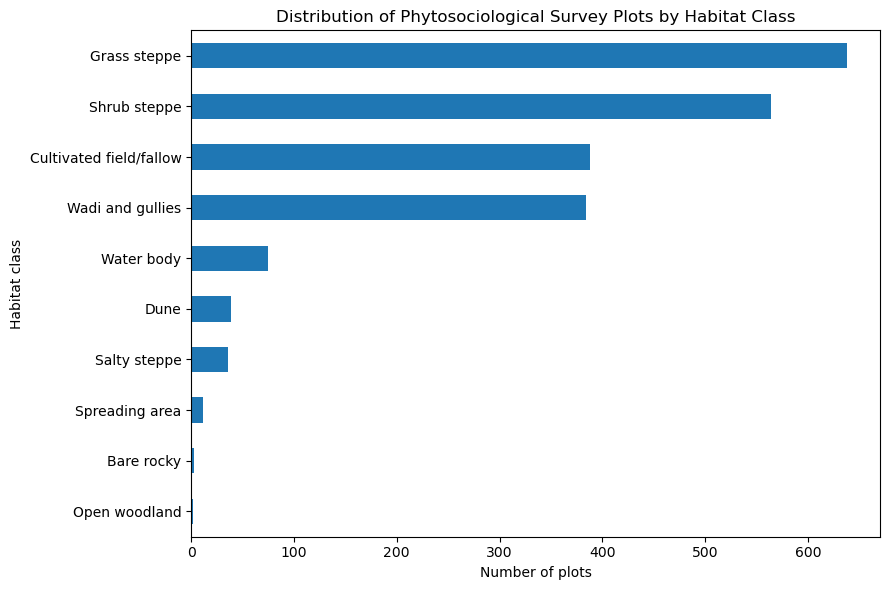

In [44]:
import matplotlib.pyplot as plt

plot_data = (
    merged["class"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 6))

plot_data.plot(kind="barh")

plt.xlabel("Number of plots")
plt.ylabel("Habitat class")
plt.title("Distribution of Phytosociological Survey Plots by Habitat Class")

plt.tight_layout()
plt.show()

In [45]:
area_numeric = pd.to_numeric(
    merged["Area_M2"],
    errors="coerce"
)

print(area_numeric.describe())

count     1991.000000
mean      2742.275239
std       2320.954758
min        120.000000
25%       1250.000000
50%       2000.000000
75%       3200.000000
max      20000.000000
Name: Area_M2, dtype: float64


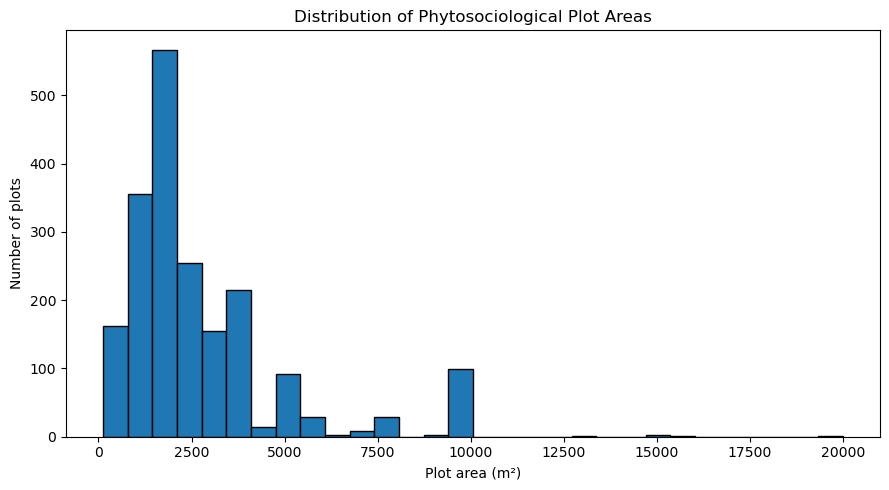

In [46]:
plt.figure(figsize=(9, 5))

plt.hist(
    area_numeric.dropna(),
    bins=30,
    edgecolor="black"
)

plt.xlabel("Plot area (m²)")
plt.ylabel("Number of plots")
plt.title("Distribution of Phytosociological Plot Areas")

plt.tight_layout()
plt.show()

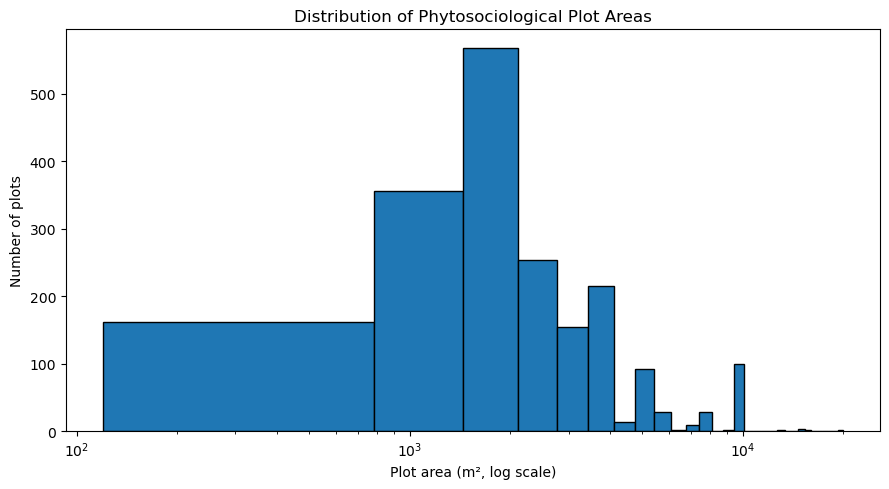

In [47]:
area_positive = area_numeric[
    area_numeric > 0
]

plt.figure(figsize=(9, 5))

plt.hist(
    area_positive,
    bins=30,
    edgecolor="black"
)

plt.xscale("log")

plt.xlabel("Plot area (m², log scale)")
plt.ylabel("Number of plots")
plt.title("Distribution of Phytosociological Plot Areas")

plt.tight_layout()
plt.show()

In [ ]:
# Explore the Class distributions
# 1 class sample-size distribution;
# 2 plot-area and equivalent-radius distributions;
# 3 plot area by habitat class;
# 4 spatial distribution map by habitat class.

,class,n,percent
0,Grass steppe,638,29.8
1,Shrub steppe,564,26.3
2,Cultivated field/fallow,388,18.1
3,Wadi and gullies,384,17.9
4,Water body,75,3.5
5,Dune,39,1.8
6,Salty steppe,36,1.7
7,Spreading area,12,0.6
8,Bare rocky,3,0.1
9,Open woodland,2,0.1


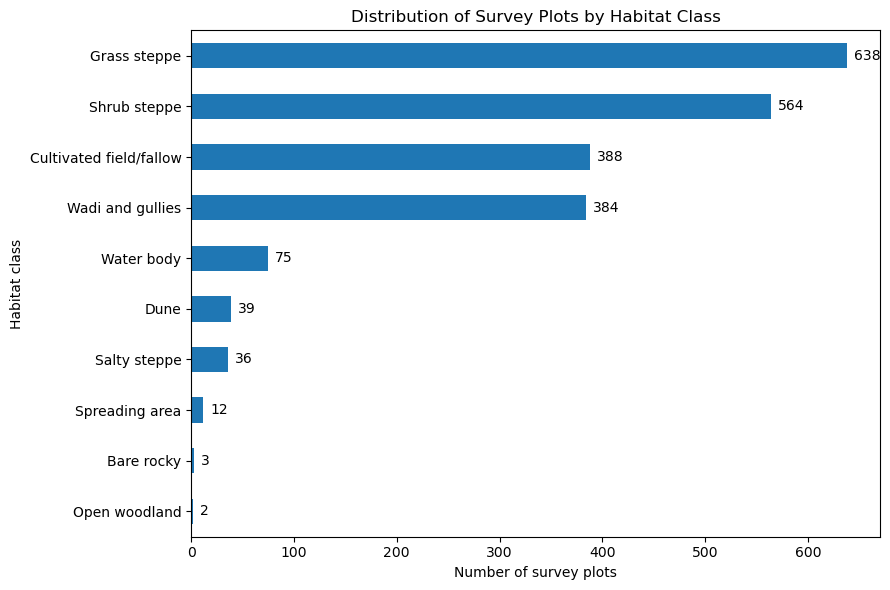

In [48]:
# 1. Class balance
import pandas as pd
import matplotlib.pyplot as plt

class_counts = (
    merged["class"]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="n")
)

class_counts["percent"] = (
    class_counts["n"] / len(merged) * 100
).round(1)

display(class_counts)

plot_data = (
    merged["class"]
    .value_counts()
    .sort_values()
)

ax = plot_data.plot(
    kind="barh",
    figsize=(9, 6)
)

ax.set_xlabel("Number of survey plots")
ax.set_ylabel("Habitat class")
ax.set_title("Distribution of Survey Plots by Habitat Class")

# Add count labels
for i, value in enumerate(plot_data):
    ax.text(
        value + max(plot_data) * 0.01,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()
plt.show()

Valid area records: 1991
Missing area records: 150


count     1991.000000
mean      2742.275239
std       2320.954758
min        120.000000
5%         600.000000
10%        900.000000
25%       1250.000000
50%       2000.000000
75%       3200.000000
90%       5000.000000
95%      10000.000000
max      20000.000000
Name: Area_M2, dtype: float64

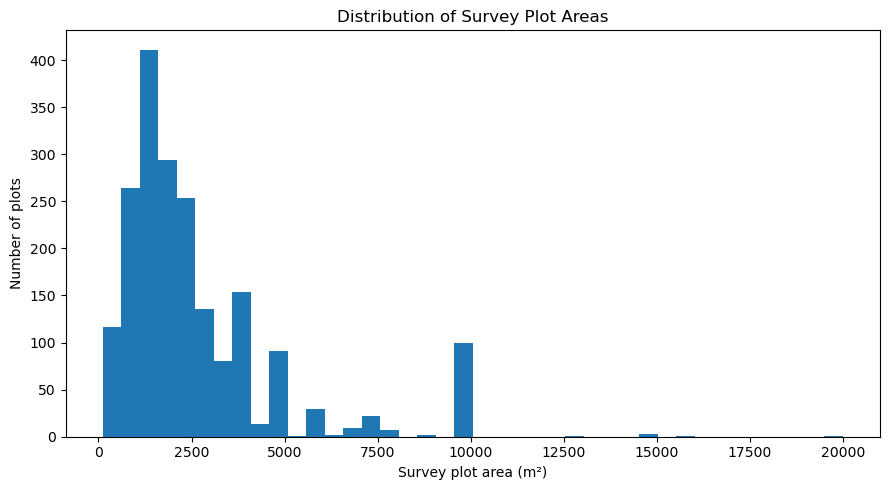

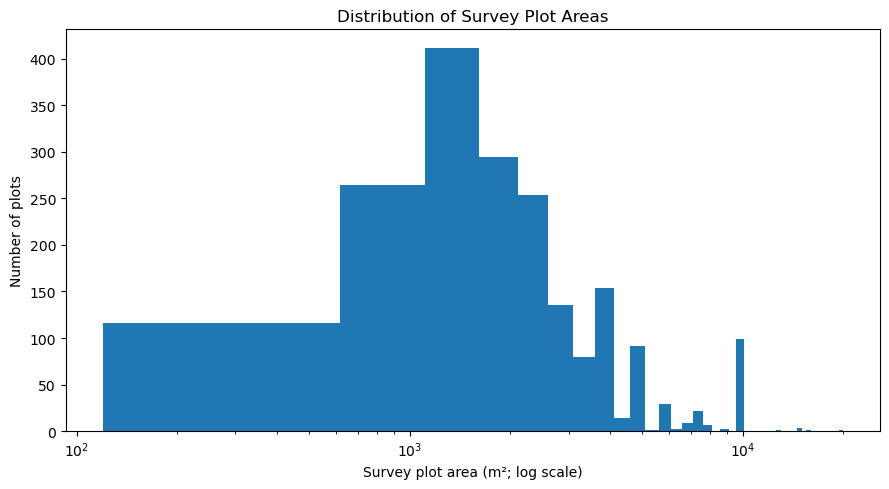

In [49]:
# 2. Analyze plot area
area = pd.to_numeric(
    merged["Area_M2"],
    errors="coerce"
)

print("Valid area records:", area.notna().sum())
print("Missing area records:", area.isna().sum())

display(area.describe(
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
))

plt.figure(figsize=(9, 5))

plt.hist(
    area.dropna(),
    bins=40
)

plt.xlabel("Survey plot area (m²)")
plt.ylabel("Number of plots")
plt.title("Distribution of Survey Plot Areas")

plt.tight_layout()
plt.show()

area_positive = area[area > 0]

plt.figure(figsize=(9, 5))

plt.hist(
    area_positive,
    bins=40
)

plt.xscale("log")

plt.xlabel("Survey plot area (m²; log scale)")
plt.ylabel("Number of plots")
plt.title("Distribution of Survey Plot Areas")

plt.tight_layout()
plt.show()

count    1991.000000
mean       27.535738
std        10.711400
min         6.180387
5%         13.819766
10%        16.925688
25%        19.947114
50%        25.231325
75%        31.915382
90%        39.894228
95%        56.418958
max        79.788456
Name: EqRadius_m, dtype: float64

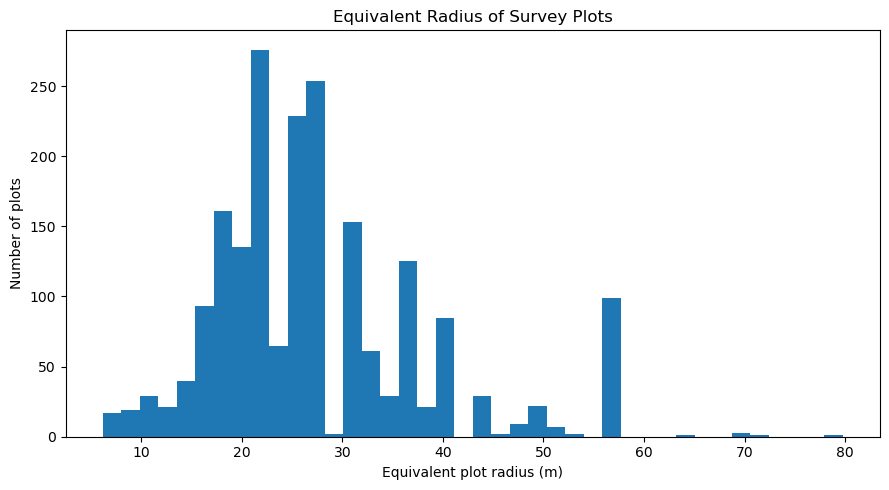

In [50]:
# 3. Calculate equivalent plot radius
import numpy as np

merged_analysis = merged.copy()

merged_analysis["Area_numeric"] = pd.to_numeric(
    merged_analysis["Area_M2"],
    errors="coerce"
)

merged_analysis["EqRadius_m"] = np.sqrt(
    merged_analysis["Area_numeric"] / np.pi
)

display(
    merged_analysis["EqRadius_m"].describe(
        percentiles=[
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
)

plt.figure(figsize=(9, 5))

plt.hist(
    merged_analysis["EqRadius_m"].dropna(),
    bins=40
)

plt.xlabel("Equivalent plot radius (m)")
plt.ylabel("Number of plots")
plt.title("Equivalent Radius of Survey Plots")

plt.tight_layout()
plt.show()

,n,median,mean,minimum,maximum
class,,,,,
Bare rocky,1,750.0,750.0,750.0,750.0
Salty steppe,23,800.0,1213.5,160.0,5000.0
Dune,32,1500.0,1759.4,200.0,5000.0
Spreading area,1,1500.0,1500.0,1500.0,1500.0
Water body,32,1550.0,2316.9,120.0,10000.0
Open woodland,2,1750.0,1750.0,1500.0,2000.0
Cultivated field/fallow,379,2000.0,2840.0,400.0,20000.0
Grass steppe,607,2000.0,2523.6,120.0,15000.0
Shrub steppe,546,2000.0,2941.1,200.0,10000.0


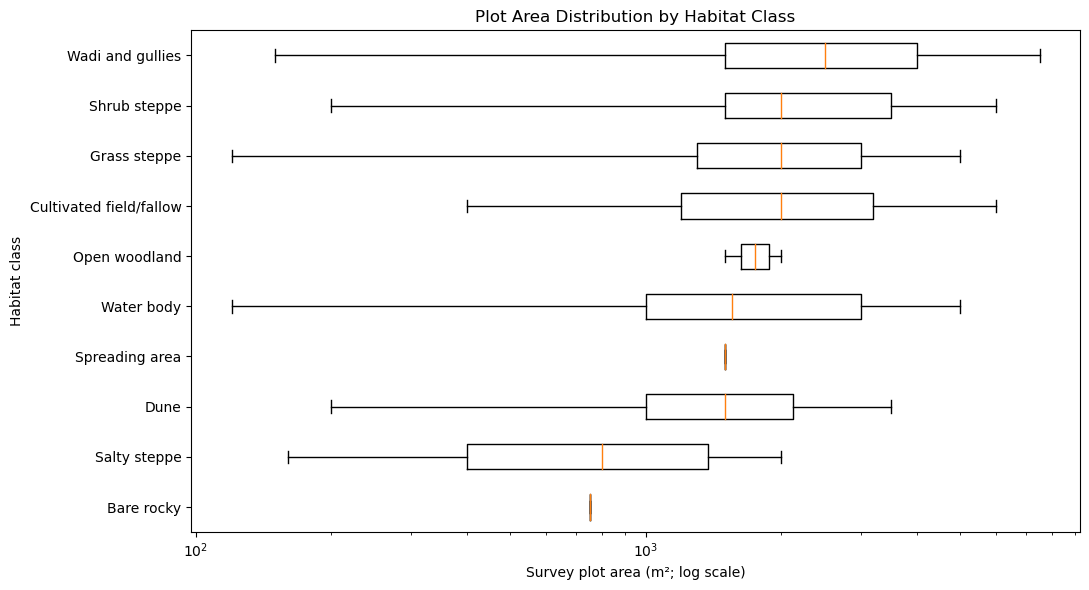

In [51]:
# 4. Area distribution by habitat class
area_by_class = (
    merged_analysis[
        merged_analysis["Area_numeric"].notna()
        & (merged_analysis["Area_numeric"] > 0)
    ]
    .groupby("class")["Area_numeric"]
    .agg(
        n="count",
        median="median",
        mean="mean",
        minimum="min",
        maximum="max"
    )
    .sort_values("median")
)

display(area_by_class.round(1))

classes = (
    area_by_class
    .sort_values("median")
    .index
    .tolist()
)

data = [
    merged_analysis.loc[
        (merged_analysis["class"] == c)
        & (merged_analysis["Area_numeric"] > 0),
        "Area_numeric"
    ].dropna().values
    for c in classes
]

plt.figure(figsize=(11, 6))

plt.boxplot(
    data,
    labels=classes,
    vert=False,
    showfliers=False
)

plt.xscale("log")

plt.xlabel("Survey plot area (m²; log scale)")
plt.ylabel("Habitat class")
plt.title("Plot Area Distribution by Habitat Class")

plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


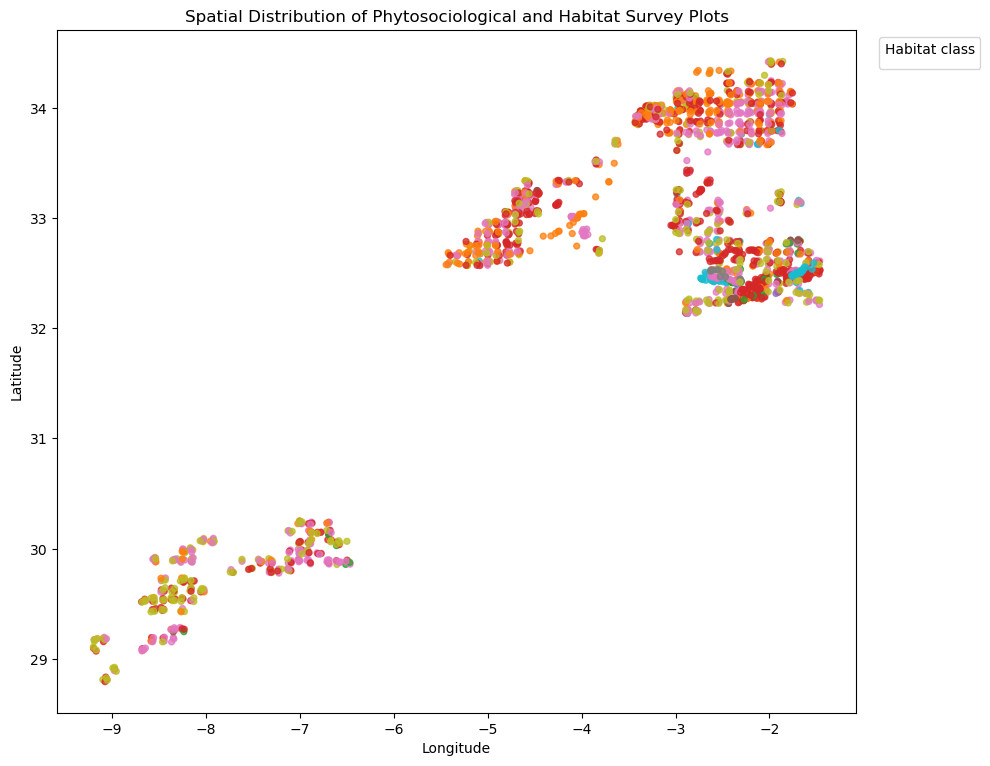

In [52]:
# 5. Spatial distribution map
fig, ax = plt.subplots(figsize=(10, 9))

merged.plot(
    ax=ax,
    column="class",
    categorical=True,
    legend=True,
    markersize=18,
    alpha=0.75
)

ax.set_title(
    "Spatial Distribution of Phytosociological and Habitat Survey Plots"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend(
    title="Habitat class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

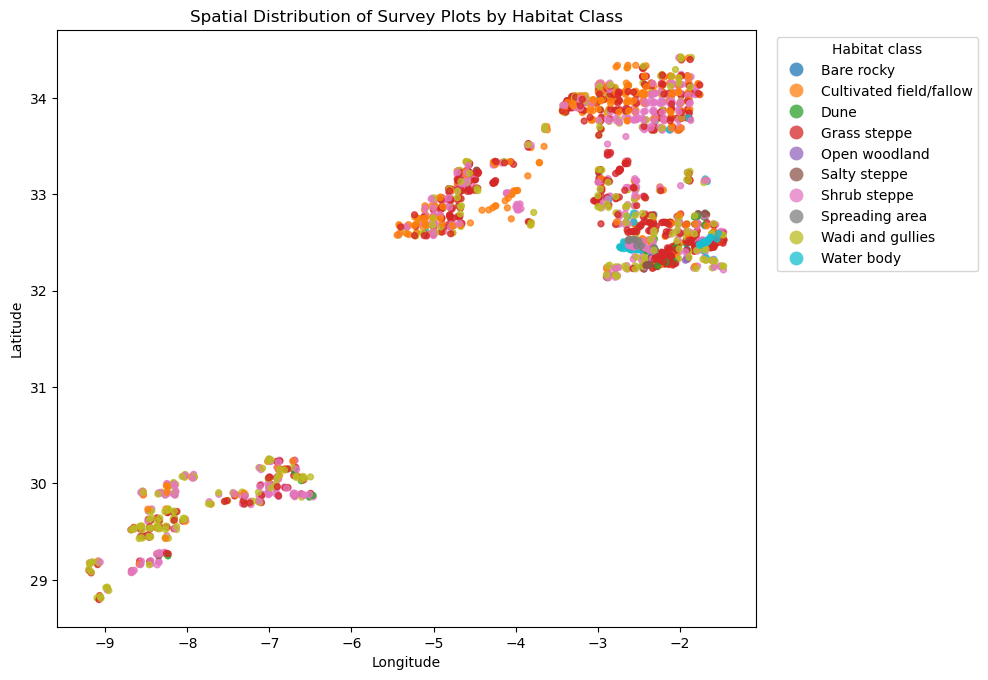

In [53]:
fig, ax = plt.subplots(figsize=(10, 9))

merged.plot(
    ax=ax,
    column="class",
    categorical=True,
    legend=True,
    markersize=18,
    alpha=0.75,
    legend_kwds={
        "title": "Habitat class",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Spatial Distribution of Survey Plots by Habitat Class"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

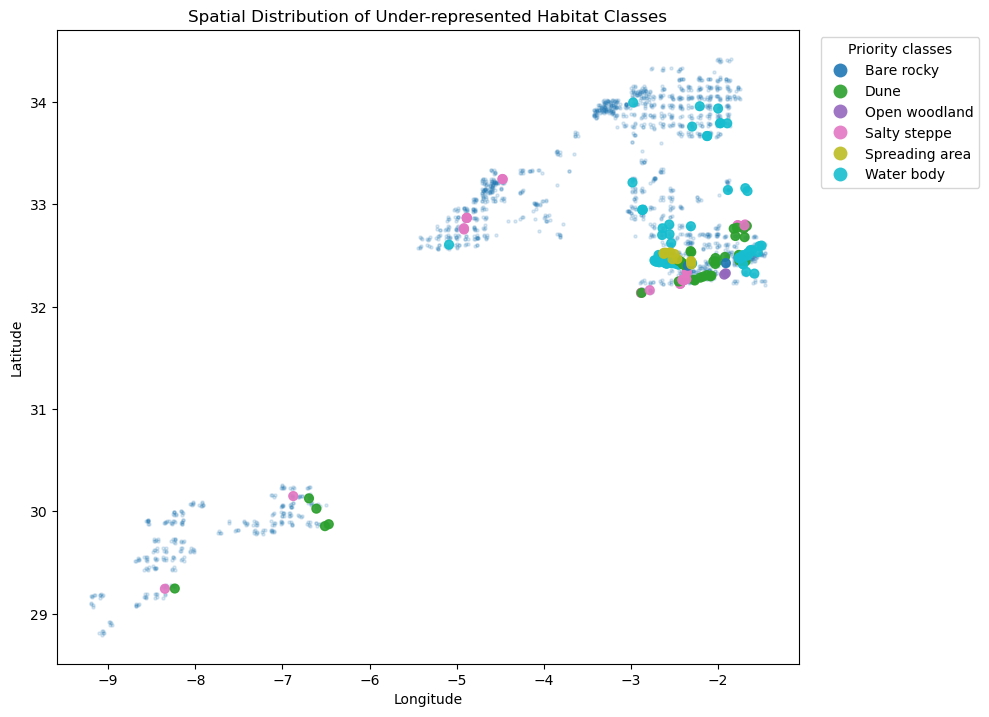

In [54]:
# Make a separate map for the rare classes
rare_classes = [
    "Open woodland",
    "Bare rocky",
    "Spreading area",
    "Salty steppe",
    "Dune",
    "Water body"
]

rare = merged[
    merged["class"].isin(rare_classes)
].copy()

fig, ax = plt.subplots(figsize=(10, 9))

# All observations in background
merged.plot(
    ax=ax,
    markersize=5,
    alpha=0.15
)

# Rare classes emphasized
rare.plot(
    ax=ax,
    column="class",
    categorical=True,
    legend=True,
    markersize=40,
    alpha=0.9,
    legend_kwds={
        "title": "Priority classes",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Spatial Distribution of Under-represented Habitat Classes"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [55]:
# calculate spatial spread numerically
spatial_summary = (
    merged
    .dropna(subset=["class"])
    .groupby("class")
    .agg(
        n=("class", "size"),
        min_lon=("Longitude", "min"),
        max_lon=("Longitude", "max"),
        min_lat=("Latitude", "min"),
        max_lat=("Latitude", "max")
    )
)

spatial_summary["lon_range"] = (
    spatial_summary["max_lon"]
    - spatial_summary["min_lon"]
)

spatial_summary["lat_range"] = (
    spatial_summary["max_lat"]
    - spatial_summary["min_lat"]
)

display(
    spatial_summary.sort_values("n")
)

,n,min_lon,max_lon,min_lat,max_lat,lon_range,lat_range
class,,,,,,,
Open woodland,2,-1.93021,-1.91263,32.31430,32.32704,0.01758,0.01274
Bare rocky,3,-2.34782,-1.91140,32.40133,32.42693,0.43642,0.02560
Spreading area,12,-2.62477,-2.30875,32.41419,32.52951,0.31602,0.11532
Salty steppe,36,-8.34942,-1.69026,29.24385,33.24879,6.65916,4.00494
Dune,39,-8.23597,-1.67088,29.24642,32.78990,6.56509,3.54348
Water body,75,-5.08866,-1.50188,32.32409,33.99611,3.58678,1.67202
Wadi and gullies,384,-9.20049,-1.46456,28.80747,34.42340,7.73593,5.61593
Cultivated field/fallow,388,-9.09849,-1.49979,29.07540,34.42340,7.59870,5.34800
Shrub steppe,564,-9.19276,-1.46386,28.89310,34.41509,7.72890,5.52199


In [56]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

eastern_path = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data"
    r"\Morocco two study areas\Eastern_Morocco_Working_Area.shp"
)

tata_path = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data"
    r"\Morocco two study areas\Tata_Morocco_Working_Area.shp"
)

eastern_boundary = gpd.read_file(eastern_path)
tata_boundary = gpd.read_file(tata_path)

print("Eastern Morocco CRS:", eastern_boundary.crs)
print("Tata CRS:", tata_boundary.crs)
print("Merged points CRS:", merged.crs)

Eastern Morocco CRS: EPSG:4326
Tata CRS: EPSG:4326
Merged points CRS: EPSG:4326


In [57]:
# Reproject points to Eastern Morocco boundary CRS
merged_em_crs = merged.to_crs(eastern_boundary.crs)

# Keep points intersecting the Eastern Morocco study area
eastern_points = gpd.sjoin(
    merged_em_crs,
    eastern_boundary[["geometry"]],
    how="inner",
    predicate="intersects"
)

# Remove spatial-join helper field
eastern_points = eastern_points.drop(
    columns=["index_right"],
    errors="ignore"
)

# Prevent duplicate points if boundary consists of overlapping polygons
eastern_points = eastern_points[
    ~eastern_points.index.duplicated(keep="first")
].copy()

print("All merged records:", len(merged))
print("Eastern Morocco records:", len(eastern_points))
print("Outside Eastern Morocco:", len(merged) - len(eastern_points))

All merged records: 2141
Eastern Morocco records: 1394
Outside Eastern Morocco: 747


In [58]:
em_class_counts = (
    eastern_points["class"]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="n")
)

em_class_counts["percent"] = (
    em_class_counts["n"] /
    len(eastern_points) * 100
).round(1)

display(em_class_counts)

,class,n,percent
0,Grass steppe,463,33.2
1,Shrub steppe,345,24.7
2,Cultivated field/fallow,223,16.0
3,Wadi and gullies,204,14.6
4,Water body,74,5.3
5,Salty steppe,34,2.4
6,Dune,34,2.4
7,Spreading area,12,0.9
8,Bare rocky,3,0.2
9,Open woodland,2,0.1


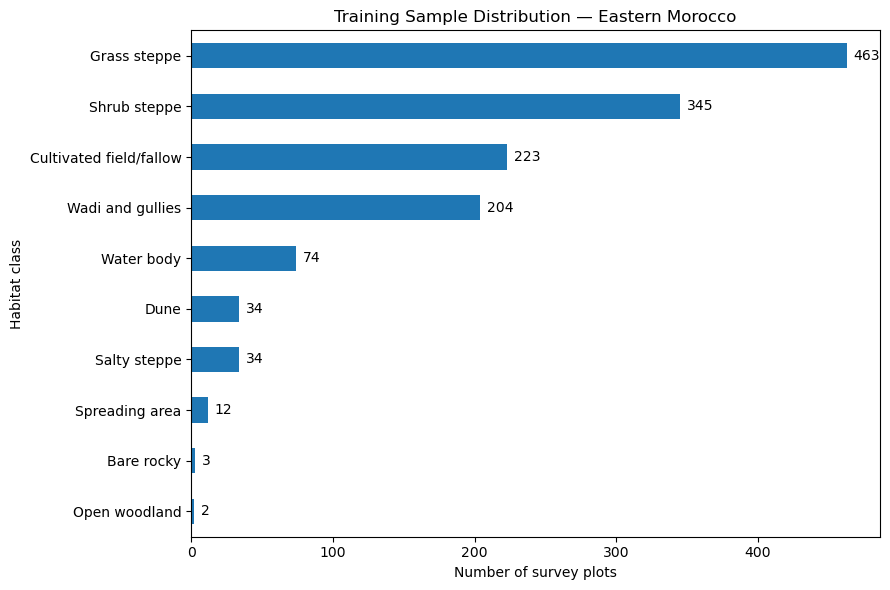

In [59]:
plot_data = (
    eastern_points["class"]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))

plot_data.plot(
    kind="barh",
    ax=ax
)

ax.set_xlabel("Number of survey plots")
ax.set_ylabel("Habitat class")
ax.set_title(
    "Training Sample Distribution — Eastern Morocco"
)

for i, n in enumerate(plot_data):
    ax.text(
        n + plot_data.max() * 0.01,
        i,
        str(n),
        va="center"
    )

plt.tight_layout()
plt.show()

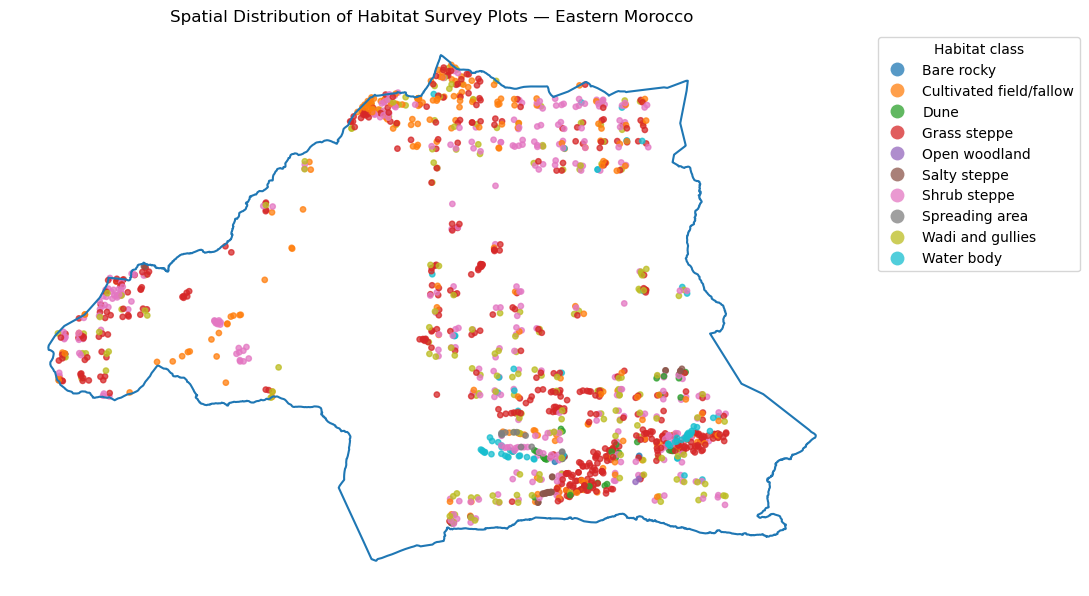

In [60]:
# Map Eastern Morocco alone
fig, ax = plt.subplots(figsize=(11, 9))

# Study-area boundary
eastern_boundary.boundary.plot(
    ax=ax,
    linewidth=1.5
)

# Survey points
eastern_points.plot(
    ax=ax,
    column="class",
    categorical=True,
    legend=True,
    markersize=15,
    alpha=0.75,
    legend_kwds={
        "title": "Habitat class",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Spatial Distribution of Habitat Survey Plots — Eastern Morocco"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [61]:
# Make the important rare-class map
priority_classes = [
    "Open woodland",
    "Bare rocky",
    "Spreading area",
    "Salty steppe",
    "Dune",
    "Water body"
]

em_priority = eastern_points[
    eastern_points["class"].isin(priority_classes)
].copy()

print(
    em_priority["class"]
    .value_counts()
)

class
Water body        74
Salty steppe      34
Dune              34
Spreading area    12
Bare rocky         3
Open woodland      2
Name: count, dtype: Int64


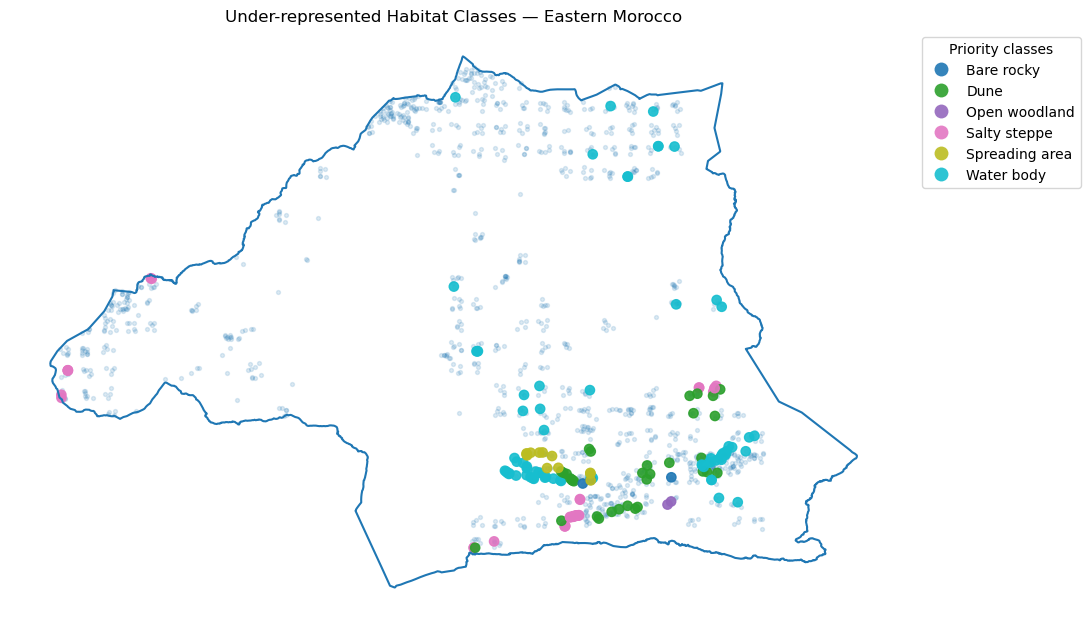

In [62]:
fig, ax = plt.subplots(figsize=(11, 9))

# Boundary
eastern_boundary.boundary.plot(
    ax=ax,
    linewidth=1.5
)

# All plots as faint background
eastern_points.plot(
    ax=ax,
    markersize=8,
    alpha=0.15
)

# Priority classes
em_priority.plot(
    ax=ax,
    column="class",
    categorical=True,
    legend=True,
    markersize=45,
    alpha=0.9,
    legend_kwds={
        "title": "Priority classes",
        "bbox_to_anchor": (1.02, 1),
        "loc": "upper left"
    }
)

ax.set_title(
    "Under-represented Habitat Classes — Eastern Morocco"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [63]:
old_for_merge = old_clean.copy()
new_for_merge = new_clean.copy()

old_for_merge["Dataset"] = "Historical"
new_for_merge["Dataset"] = "2026"

merged_source = gpd.GeoDataFrame(
    pd.concat(
        [old_for_merge, new_for_merge],
        ignore_index=True,
        sort=False
    ),
    geometry="geometry",
    crs=old_for_merge.crs
)

merged_source_em = merged_source.to_crs(
    eastern_boundary.crs
)

eastern_source = gpd.sjoin(
    merged_source_em,
    eastern_boundary[["geometry"]],
    how="inner",
    predicate="intersects"
).drop(
    columns="index_right",
    errors="ignore"
)

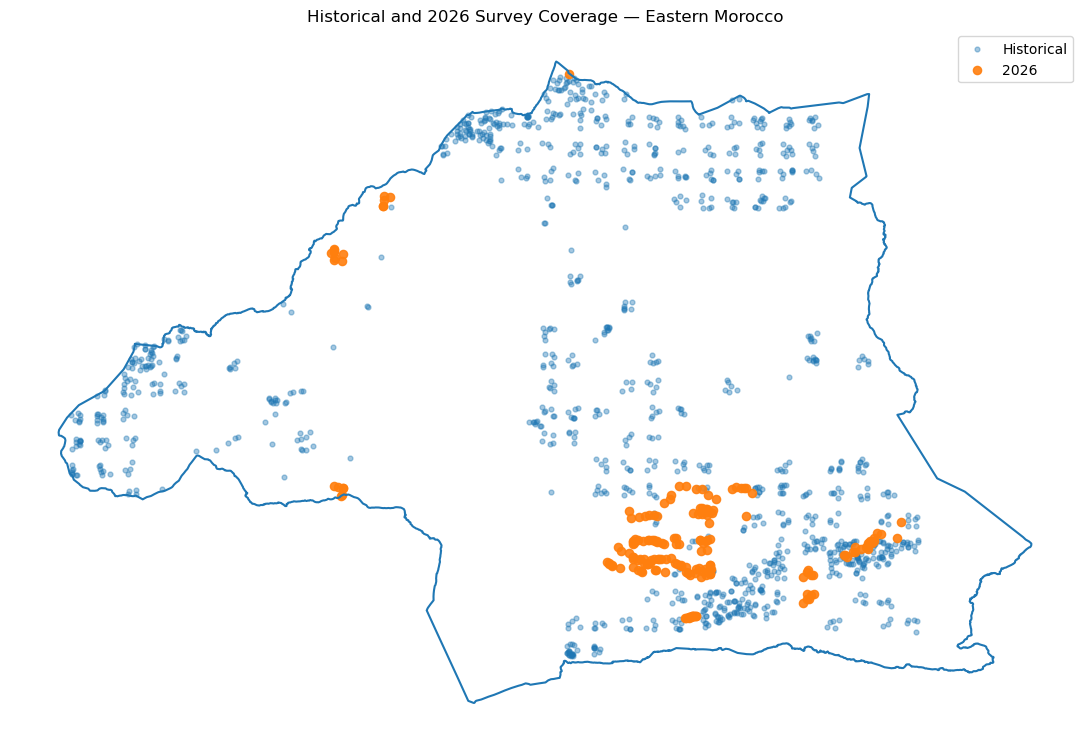

In [64]:
fig, ax = plt.subplots(figsize=(11, 9))

eastern_boundary.boundary.plot(
    ax=ax,
    linewidth=1.5
)

eastern_source[
    eastern_source["Dataset"] == "Historical"
].plot(
    ax=ax,
    markersize=12,
    alpha=0.4,
    label="Historical"
)

eastern_source[
    eastern_source["Dataset"] == "2026"
].plot(
    ax=ax,
    markersize=35,
    alpha=0.9,
    label="2026"
)

ax.legend()
ax.set_title(
    "Historical and 2026 Survey Coverage — Eastern Morocco"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [65]:
# Plot-area statistics for Eastern Morocco only
eastern_points["Area_numeric"] = pd.to_numeric(
    eastern_points["Area_M2"],
    errors="coerce"
)

display(
    eastern_points["Area_numeric"].describe(
        percentiles=[
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
)

em_area_summary = (
    eastern_points[
        eastern_points["Area_numeric"] > 0
    ]
    .groupby("class")["Area_numeric"]
    .agg(
        n_area="count",
        median_area="median",
        mean_area="mean",
        min_area="min",
        max_area="max"
    )
    .sort_values("median_area")
)

display(em_area_summary.round(1))

count     1246.000000
mean      2798.410915
std       2563.257893
min        120.000000
5%         500.000000
10%        750.000000
25%       1250.000000
50%       2000.000000
75%       3200.000000
90%       6000.000000
95%      10000.000000
max      16000.000000
Name: Area_numeric, dtype: float64

,n_area,median_area,mean_area,min_area,max_area
class,,,,,
Bare rocky,1,750.0,750.0,750.0,750.0
Salty steppe,21,750.0,1091.0,160.0,5000.0
Dune,27,1500.0,1566.7,200.0,5000.0
Spreading area,1,1500.0,1500.0,1500.0,1500.0
Water body,31,1600.0,2359.4,120.0,10000.0
Open woodland,2,1750.0,1750.0,1500.0,2000.0
Cultivated field/fallow,214,2000.0,3023.4,400.0,12800.0
Grass steppe,432,2000.0,2553.2,120.0,15000.0
Shrub steppe,327,2000.0,3191.7,200.0,10000.0


In [69]:
# eastern_points.head

In [68]:
for col in eastern_points.columns:
    if len(col) > 10:
        print(col, len(col))

Area_numeric 12


In [70]:
final_fields = [
    "Station_ID",
    "Station_Na",
    "Latitude",
    "Longitude",
    "Area_M2",
    "Exposure",
    "Slope_Clas",
    "class",
    "geometry"
]

eastern_final = eastern_points[final_fields].copy()

from pathlib import Path

output_em = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data"
    r"\Reneco\Vegetation Cover and Food Availability Studies"
    r"\Phytosociological_Survey_Eastern_Morocco_2008_2026.shp"
)

eastern_final.to_file(output_em)

print("Saved:")
print(output_em)
print("Records:", len(eastern_final))
print("Fields:", eastern_final.columns.tolist())

Saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\Phytosociological_Survey_Eastern_Morocco_2008_2026.shp
Records: 1394
Fields: ['Station_ID', 'Station_Na', 'Latitude', 'Longitude', 'Area_M2', 'Exposure', 'Slope_Clas', 'class', 'geometry']


In [71]:
output_gpkg = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data"
    r"\Reneco\Vegetation Cover and Food Availability Studies"
    r"\Phytosociological_Survey_Eastern_Morocco_2008_2026.gpkg"
)

eastern_points.to_file(
    output_gpkg,
    layer="Eastern_Morocco",
    driver="GPKG"
)